In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import
import pandas as pd

sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [23]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import optuna

In [18]:
features_df = pd.read_csv("../src/features/quaterly_with_ent_rate4.csv", index_col=0)
target_df = pd.read_csv("../src/metrics&entropy_M4.csv", index_col=0)
target_df = target_df[target_df.index.str.startswith('Q')]['smape']

In [19]:
features_df.columns = pd.Series(features_df.columns).apply(lambda x: x.replace('"','')).to_list()

In [21]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 256, 512),
    }

    X_train, X_test, y_train, y_test = train_test_split(features_df, target_df, test_size=0.2, random_state=42)

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    return mae

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, n_jobs = 6)

best_params = study.best_params
print("Best params:", best_params)

[I 2024-05-13 18:56:01,377] A new study created in memory with name: no-name-f97baf5f-bb21-4798-9211-02057c7649b2
[I 2024-05-13 18:56:03,274] Trial 4 finished with value: 0.03292003474239312 and parameters: {'lambda_l1': 4.226258933301073e-06, 'lambda_l2': 1.1507621568839291e-05, 'num_leaves': 42, 'feature_fraction': 0.7698246714834034, 'bagging_fraction': 0.6826925006004694, 'bagging_freq': 5, 'min_child_samples': 83, 'learning_rate': 0.006252223156331014, 'n_estimators': 438}. Best is trial 4 with value: 0.03292003474239312.
[I 2024-05-13 18:56:04,163] Trial 2 finished with value: 0.031855139506580886 and parameters: {'lambda_l1': 0.18979223376163273, 'lambda_l2': 3.6940280610279683, 'num_leaves': 173, 'feature_fraction': 0.7417588082706422, 'bagging_fraction': 0.6984857730047205, 'bagging_freq': 7, 'min_child_samples': 81, 'learning_rate': 0.018504751526486337, 'n_estimators': 291}. Best is trial 2 with value: 0.031855139506580886.
[I 2024-05-13 18:56:04,637] Trial 3 finished with v

Best params: {'lambda_l1': 2.6391874500503386e-08, 'lambda_l2': 0.001334853902564615, 'num_leaves': 242, 'feature_fraction': 0.6317233049269967, 'bagging_fraction': 0.9367576240147715, 'bagging_freq': 1, 'min_child_samples': 5, 'learning_rate': 0.017825231809069027, 'n_estimators': 486}
[LightGBM] [Warning] feature_fraction is set=0.6317233049269967, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6317233049269967
[LightGBM] [Warning] lambda_l1 is set=2.6391874500503386e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.6391874500503386e-08
[LightGBM] [Warning] lambda_l2 is set=0.001334853902564615, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.001334853902564615
[LightGBM] [Warning] bagging_fraction is set=0.9367576240147715, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9367576240147715
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] fea

LGBMRegressor(bagging_fraction=0.9367576240147715, bagging_freq=1,
              feature_fraction=0.6317233049269967,
              lambda_l1=2.6391874500503386e-08, lambda_l2=0.001334853902564615,
              learning_rate=0.017825231809069027, min_child_samples=5,
              n_estimators=486, num_leaves=242)

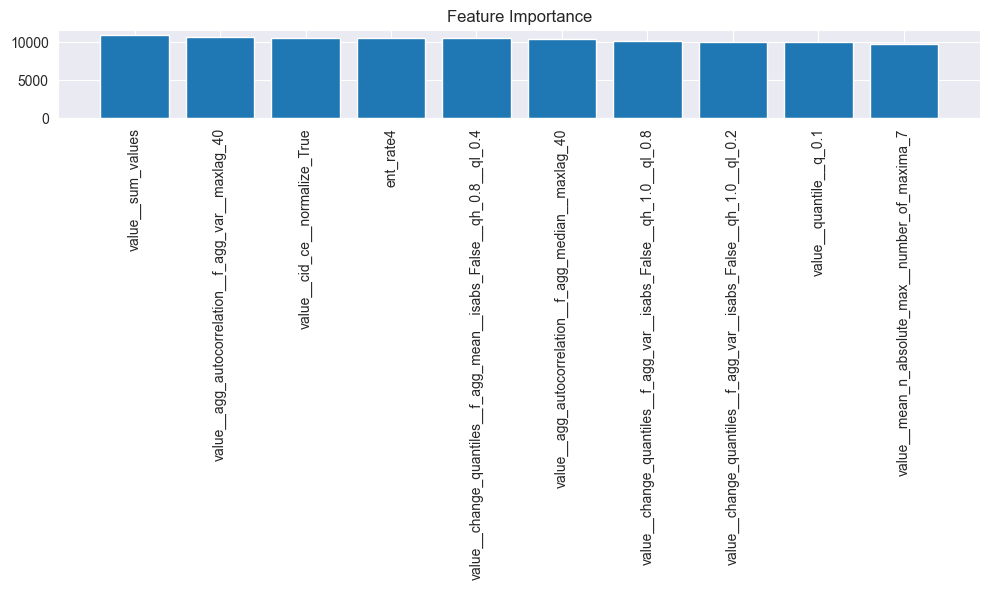

In [22]:
# Важность признаков
feature_importance = best_model.feature_importances_
sorted_idx = feature_importance.argsort()[::-1]

# Вывод 10 самых важных признаков
top_features = 10
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(top_features), feature_importance[sorted_idx][:top_features], align="center")
plt.xticks(range(top_features), features_df.columns[sorted_idx][:top_features], rotation=90)
plt.tight_layout()
plt.show()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(features_df, target_df, test_size=0.2, random_state=42)
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
smape_metric = symmetric_mean_absolute_percentage_error(y_test, preds)
rsquare = r2_score(y_test, preds)
print("Mean Absolute Error: %.5f" % mae)
print("Symmetric Mean Absolute Percentage Error: %.5f" % smape_metric)
print("R-square: %.5f" % rsquare)

[LightGBM] [Warning] feature_fraction is set=0.6317233049269967, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6317233049269967
[LightGBM] [Warning] lambda_l1 is set=2.6391874500503386e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.6391874500503386e-08
[LightGBM] [Warning] lambda_l2 is set=0.001334853902564615, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.001334853902564615
[LightGBM] [Warning] bagging_fraction is set=0.9367576240147715, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9367576240147715
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.6317233049269967, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6317233049269967
[LightGBM] [Warning] lambda_l1 is set=2.6391874500503386e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.6391874500503386e-08
[LightGBM] [Warni

In [31]:
X_train, X_test, y_train, y_test = train_test_split(features_df.drop(['ent_rate4'], axis=1), target_df, test_size=0.2, random_state=42)
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
smape_metric = symmetric_mean_absolute_percentage_error(y_test, preds)
rsquare = r2_score(y_test, preds)
print("Mean Absolute Error: %.5f" % mae)
print("Symmetric Mean Absolute Percentage Error: %.5f" % smape_metric)
print("R-square: %.5f" % rsquare)

[LightGBM] [Warning] feature_fraction is set=0.6317233049269967, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6317233049269967
[LightGBM] [Warning] lambda_l1 is set=2.6391874500503386e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.6391874500503386e-08
[LightGBM] [Warning] lambda_l2 is set=0.001334853902564615, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.001334853902564615
[LightGBM] [Warning] bagging_fraction is set=0.9367576240147715, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9367576240147715
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.6317233049269967, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6317233049269967
[LightGBM] [Warning] lambda_l1 is set=2.6391874500503386e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.6391874500503386e-08
[LightGBM] [Warni

,value__sum_values,value__change_quantiles__f_agg_var__isabs_False__qh_1.0__ql_0.2,value__change_quantiles__f_agg_mean__isabs_False__qh_0.8__ql_0.4,value__change_quantiles__f_agg_var__isabs_False__qh_1.0__ql_0.8,value__augmented_dickey_fuller__attr_usedlag__autolag_AIC,value__mean_n_absolute_max__number_of_maxima_7,value__quantile__q_0.1,value__cid_ce__normalize_True,value__variation_coefficient,value__agg_autocorrelation__f_agg_median__maxlag_40,value__agg_autocorrelation__f_agg_var__maxlag_40
Q1,180887.003125,65884.041380,-54.404276,3.193375e+03,2.0,7718.498974,6635.896052,3.600123,0.059901,0.122784,0.589759
Q2,186523.583493,89582.423975,-73.835825,4.708505e+00,5.0,8032.877652,6877.840306,3.278226,0.062034,0.044351,0.667796
Q3,199910.304733,203665.440916,-95.932132,2.530595e+03,0.0,8676.982917,7194.621703,3.654678,0.076222,0.031605,0.477528
Q4,202918.966414,94823.450799,-106.462815,2.080601e+02,0.0,8667.572608,7534.424773,3.664353,0.057679,-0.041900,0.467195
Q5,89192.000000,435258.553583,163.571429,9.216000e+03,3.0,2489.428571,908.000000,8.888150,0.337892,-0.055220,0.043032
...,...,...,...,...,...,...,...,...,...,...,...
Q23996,171320.000000,2460.465976,9.333333,5.687500e+02,12.0,2391.428571,2240.000000,9.756884,0.022914,0.036304,0.036362
Q23997,599050.000000,53962.760000,47.826087,4.482431e+04,12.0,9758.571429,6906.000000,7.152311,0.119579,0.192065,0.130744
Q23998,599050.000000,53962.760000,47.826087,4.482431e+04,12.0,9758.571429,6906.000000,7.152311,0.119579,0.192065,0.130744
Q23999,108801.000555,34127.317318,4.943504,1.317855e+05,11.0,3661.561521,724.497140,5.387563,0.534916,-0.344321,0.187194
